# 08 - Multidimensional Pie Hovmoller Prototype

Independent, publication-style prototype for process-budget visualization:
- confidence heat map in time-height space,
- sparse pie charts for local process composition,
- contour context for total activity.

This notebook is self-contained and does not require variables from other notebooks.

In [2]:
"""Setup: imports, repository paths, and scientific plot style."""
from __future__ import annotations

from contextlib import nullcontext
from pathlib import Path
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import numpy as np
import xarray as xr

xr.set_options(keep_attrs=True)
warnings.filterwarnings('ignore', category=RuntimeWarning)

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utilities.process_rates import build_rates_for_experiments
from utilities.style_profiles import FULL_COL_IN, MM, proc_color, use_style

RATE_FLOOR = 1e-18
TIME_COARSEN = '30s'
SEED_START = np.datetime64('2023-01-25T12:30:00')
LBB = slice(30, 50)   # liquid cloud bins
CBB = slice(50, 66)   # precipitation/ice-forward bins
PLOT_EXP_IDS = [0]
STATION_LABELS = ['Station 1', 'Station 2']

print(f'Repo root: {REPO_ROOT}')
print(f'Source dir: {SRC_DIR}')

Repo root: /Users/schimmel/Library/Mobile Documents/com~apple~CloudDocs/code/polarcap/python/polarcap_analysis
Source dir: /Users/schimmel/Library/Mobile Documents/com~apple~CloudDocs/code/polarcap/python/polarcap_analysis/src


In [3]:
"""Data helpers: load real model dataset when available, else synthetic fallback."""
def discover_candidate_datasets(repo_root: Path) -> list[Path]:
    patterns = [
        '**/*meteogram*.zarr',
        '**/*meteogram*.nc',
        '**/*lv3*rates*.zarr',
        '**/*lv3*rates*.nc',
    ]
    cands = []
    for patt in patterns:
        cands.extend(repo_root.glob(patt))
    # Keep likely analysis data first, deterministic order.
    cands = sorted({p for p in cands if 'archive' not in p.parts})
    return cands

def open_dataset_auto(path: Path) -> xr.Dataset:
    if path.suffix == '.zarr':
        return xr.open_zarr(path)
    return xr.open_dataset(path)

def make_synthetic_rates(n_time=180, n_height=52, n_station=2):
    rng = np.random.default_rng(42)
    procs = [
        'CONDENSATION', 'DROP_COLLISION', 'RIMING', 'MELTING',
        'DEPOSITION', 'IMMERSION_FREEZING',
    ]
    t0 = np.datetime64('2023-01-25T12:00:00')
    time = t0 + np.arange(n_time) * np.timedelta64(10, 's')
    z = np.linspace(400.0, 2600.0, n_height)

    rates = {}
    tt = np.linspace(0.0, 1.0, n_time)[:, None, None]
    zz = np.linspace(0.0, 1.0, n_height)[None, :, None]
    ss = np.linspace(0.9, 1.1, n_station)[None, None, :]
    for k, p in enumerate(procs):
        phase_t = np.sin(2.0 * np.pi * (tt * (1.0 + 0.2 * k) + 0.1 * k))
        phase_z = np.cos(np.pi * (zz * (1.0 + 0.1 * k)))
        core = np.abs(phase_t * phase_z) * (1.0 + 0.25 * k)
        burst = np.exp(-((tt - (0.35 + 0.07 * k)) ** 2) / (0.002 + 0.0008 * k))
        noise = 0.08 * rng.random((n_time, n_height, n_station))
        arr = (core + 0.9 * burst) * ss + noise
        arr = 3e-13 * np.maximum(arr, 0.0)
        rates[p] = xr.DataArray(
            arr,
            dims=('time', 'height_level', 'station'),
            coords={'time': time, 'height_level': z, 'station': np.arange(n_station)},
            name=p,
        )
    return {
        0: {
            'exp_label': 'synthetic_demo',
            'unit_N': r'cm$^{-3}$ s$^{-1}$',
            'unit_Q': r'g cm$^{-3}$ s$^{-1}$',
            'rates_N_liq': rates,
        }
    }

def build_rates_by_exp_from_dataset(ds: xr.Dataset, exp_ids: list[int] | None = None):
    if exp_ids is None:
        exp_ids = [0] if 'expname' not in ds.dims else list(range(ds.sizes['expname']))
    rates_by_exp, _ = build_rates_for_experiments(
        ds=ds,
        exp_ids=exp_ids,
        config=None,
        LBB=LBB,
        CBB=CBB,
        repo_root=REPO_ROOT,
    )
    return rates_by_exp

In [4]:
# ---------------------------------------------------------------------------
# Core figure: confidence Hovmoller + multidimensional pie overlays
# ---------------------------------------------------------------------------
# This cell defines the main plotting function. Modify here to change:
#   - Confidence colormap (conf_cmap)
#   - Pie grid density (n_time_pies, n_height_pies) or pie_size_range
#   - Contour levels for log_total
#   - Legend placement (bbox_to_anchor, ncol)
#   - Axis labels and date formatting
# ---------------------------------------------------------------------------


def stn_label(si: int) -> str:
    """Return display label for station index. Uses STATION_LABELS from setup cell."""
    return STATION_LABELS[si] if si < len(STATION_LABELS) else f'Station {si + 1}'


def plot_hovmoller_multidim_pie(
    rates_dict: dict[str, xr.DataArray],
    unit_label: str,
    spectrum_label: str,
    *,
    exp_label: str = 'exp',
    exclude_processes: list[str] | None = None,
    n_time_pies: int = 11,
    n_height_pies: int = 8,
    pie_size_range: tuple[float, float] = (0.045, 0.090),
):
    """
    Draw time-height Hovmoller with confidence background and pie-chart overlays.

    Background: dominance confidence = max(|rate|) / sum(|rate|) per (time, height).
    Overlay: sparse pie charts on a regular grid; pie size encodes local total activity.
    Optional thin contours show log10(sum|rate|) for magnitude context.

    When one process (e.g. CONDENSATION) dominates, set exclude_processes to that
    name so confidence and pie composition are computed over the remaining
    processes only; this reveals structure of the smaller terms.

    Parameters
    ----------
    rates_dict : dict[str, xr.DataArray]
        Process name -> DataArray with dims (time, height_level[, station]).
        Values are signed rates; we use absolute values for composition and confidence.
    unit_label : str
        LaTeX-friendly unit string for the rate (e.g. r"cm$^{-3}$ s$^{-1}$").
    spectrum_label : str
        Short description for the figure title (e.g. "Liquid - number (cloud bins)").
    exp_label : str, optional
        Experiment label for the title (default "exp").
    exclude_processes : list[str], optional
        Process names to exclude (e.g. ["CONDENSATION"]). Composition and
        confidence use only the remaining processes so smaller terms are visible.
    n_time_pies : int, optional
        Number of time indices at which to draw pies (default 11).
    n_height_pies : int, optional
        Number of height indices at which to draw pies (default 8).
    pie_size_range : tuple[float, float], optional
        (min, max) pie size in axes coordinates (default (0.045, 0.090)).
        Min used where total activity is low, max where it is high (10–90 % quantile).

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : list of matplotlib.axes.Axes
        One axis per station.

    Notes
    -----
    - Expects globals: TIME_COARSEN, RATE_FLOOR, SEED_START, STATION_LABELS,
      use_style, proc_color, FULL_COL_IN, MM.
    - Pies are drawn only where sum(|rate|) of included processes > RATE_FLOOR.
    - To change confidence colors, edit the LinearSegmentedColormap.from_list call.
    """
    style_ctx = use_style('publication') if 'use_style' in globals() else nullcontext()
    with style_ctx:
        procs_all = list(rates_dict.keys())
        if exclude_processes:
            procs = [p for p in procs_all if p not in exclude_processes]
            if not procs:
                procs = procs_all
        else:
            procs = procs_all
        colors = [proc_color(p) for p in procs]
        n_stations = int(rates_dict[procs[0]].sizes.get('station', 1))

        # Figure layout: one column per station, shared y-axis
        fig, axes = plt.subplots(
            1, n_stations, figsize=(FULL_COL_IN, 80 * MM), constrained_layout=True, sharey=True
        )
        if n_stations == 1:
            axes = [axes]

        # Confidence colormap: low (0) = light, high (1) = dark blue (change hex list to restyle)
        conf_cmap = LinearSegmentedColormap.from_list(
            'confidence_cmap', ['#f7fcf0', '#ccebc5', '#7bccc4', '#2b8cbe', '#084081']
        )
        conf_im = None

        for si, ax in enumerate(axes):
            # Per-station: resample time, ensure height is sorted for pcolormesh/contour
            series = {
                p: rates_dict[p].isel(station=si).resample(time=TIME_COARSEN).mean().compute()
                for p in procs
            }
            tvals = series[procs[0]].time.values
            zvals = series[procs[0]].height_level.values
            z_order = np.argsort(zvals)
            z_sorted = zvals[z_order]
            t_num = mdates.date2num(tvals)

            # Arrays: (n_proc, time, height); total_abs (time, height)
            abs_rates = np.array([np.abs(series[p].values[:, z_order]) for p in procs])
            total_abs = abs_rates.sum(axis=0)
            confidence = np.nanmax(abs_rates, axis=0) / np.where(total_abs > RATE_FLOOR, total_abs, np.nan)
            log_total = np.log10(np.where(total_abs > RATE_FLOOR, total_abs, np.nan))

            # Background: confidence field
            conf_im = ax.pcolormesh(
                t_num, z_sorted, confidence.T, cmap=conf_cmap, shading='nearest',
                vmin=0.0, vmax=1.0, alpha=0.96
            )

            # Optional contours of log10(total |rate|) for magnitude context
            if np.isfinite(log_total).any():
                lev = np.nanpercentile(log_total[np.isfinite(log_total)], [30, 50, 70, 90])
                ax.contour(t_num, z_sorted, log_total.T, levels=np.unique(lev), colors='k', linewidths=0.35, alpha=0.35)

            # Normalised total for pie size: 0 at 10th percentile, 1 at 90th
            finite_total = total_abs[np.isfinite(total_abs) & (total_abs > RATE_FLOOR)]
            if finite_total.size:
                q10, q90 = np.quantile(finite_total, [0.10, 0.90])
                size_norm = np.clip((total_abs - q10) / max(q90 - q10, 1e-20), 0.0, 1.0)
            else:
                size_norm = np.zeros_like(total_abs)

            # Pie grid: indices uniformly spaced in time and height
            tidx = np.unique(np.linspace(0, len(t_num) - 1, n_time_pies, dtype=int))
            zidx = np.unique(np.linspace(0, len(z_sorted) - 1, n_height_pies, dtype=int))
            xmin, xmax = float(np.min(t_num)), float(np.max(t_num))
            zmin, zmax = float(np.min(z_sorted)), float(np.max(z_sorted))

            for it in tidx:
                for iz in zidx:
                    vals = abs_rates[:, it, iz]
                    tot = vals.sum()
                    if not np.isfinite(tot) or tot <= RATE_FLOOR:
                        continue
                    ratios = vals / tot
                    # Position pie in axes coords (0–1) from data coords
                    xfrac = (t_num[it] - xmin) / max(xmax - xmin, 1e-12)
                    yfrac = (z_sorted[iz] - zmin) / max(zmax - zmin, 1e-12)
                    psize = pie_size_range[0] + (pie_size_range[1] - pie_size_range[0]) * size_norm[it, iz]
                    iax = ax.inset_axes([xfrac - psize / 2, yfrac - psize / 2, psize, psize], transform=ax.transAxes)
                    iax.pie(
                        ratios, colors=colors, startangle=90, counterclock=False,
                        wedgeprops={'linewidth': 0.25, 'edgecolor': '0.15', 'alpha': 0.96}
                    )
                    iax.set_aspect('equal')
                    iax.set_xticks([])
                    iax.set_yticks([])
                    iax.patch.set_alpha(0.0)

            # Seeding marker, labels, date format
            ax.axvline(mdates.date2num(SEED_START), color='w', lw=0.9, ls='--', zorder=5, alpha=0.95)
            ax.set_title(stn_label(si), fontweight='bold')
            ax.set_xlabel('Time [UTC]')
            if si == 0:
                ax.set_ylabel('Height [m]')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(25)
                lbl.set_ha('right')

        # Shared colorbar for confidence
        if conf_im is not None:
            fig.colorbar(
                conf_im, ax=list(axes), label='Dominance confidence (max |rate| / Sum|rate|)',
                shrink=0.86, pad=0.02
            )

        # Process legend (pie colors)
        proc_handles = [Patch(facecolor=c, edgecolor='0.2', linewidth=0.4, label=p) for p, c in zip(procs, colors)]
        fig.legend(handles=proc_handles, loc='lower center', ncol=min(6, len(procs)), frameon=False, bbox_to_anchor=(0.5, -0.06))

        # Size legend (pie diameter meaning)
        size_handles = [
            plt.Line2D([0], [0], marker='o', linestyle='', markersize=5.5, markerfacecolor='0.7', markeredgecolor='0.2', label='lower Sum|rate|'),
            plt.Line2D([0], [0], marker='o', linestyle='', markersize=9.0, markerfacecolor='0.7', markeredgecolor='0.2', label='higher Sum|rate|'),
        ]
        fig.legend(
            handles=size_handles, loc='upper right', ncol=1, frameon=False, bbox_to_anchor=(0.95, 0.05),
            title=''
        )

        exclude_suffix = ' (excluding ' + ', '.join(exclude_processes) + ')' if exclude_processes else ''
        fig.suptitle(
            f'Pie diameter scales with local total activity\n{spectrum_label}{exclude_suffix}\n(exp {exp_label}, unit: {unit_label})',
            fontweight='bold',
        )
        return fig, axes

# MAIN  

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False
Figure widths — single: 89 mm  |  full: 183 mm  |  max height: 247 mm


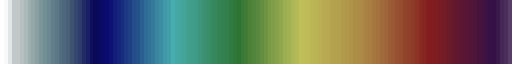

In [5]:
#
from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())
#
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
# 
from utilities.plotting import create_new_jet3, create_fade_cmap, make_pastel
from utilities.namelist_metadata import metadata_manager
from utilities.meteogram_io import _compute_bin_coords
from utilities.style_profiles import (
    apply_publication_style, save_fig, SINGLE_COL_IN, FULL_COL_IN, MAX_H_IN, MM, PROC_COLORS, proc_color,
    ENERGY_PROCESSES, HEAT_RELEASE_PROCESSES, HEAT_CONSUME_PROCESSES,
)
# Publication figure style (utilities.style_profiles: 89/183 mm, 300 DPI, Okabe-Ito)
apply_publication_style()
print(f"Figure widths — single: {SINGLE_COL_IN * 25.4:.0f} mm  |  full: {FULL_COL_IN * 25.4:.0f} mm  |  max height: {MAX_H_IN * 25.4:.0f} mm")
new_jet = create_fade_cmap(make_pastel(create_new_jet3(256), 0.5, 0.8), 4)
new_jet

In [6]:
cs_run = "cs-eriswil__20260304_110254"

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run

zarr_candidates = sorted(data_dir.glob("Meteogram_*.zarr"))
zarr_path = zarr_candidates[-1] if zarr_candidates else None
print(f"Zarr store: {zarr_path}")

# Bin ranges — index into the 66-bin spectral grid
# Bins  0-29:  aerosol / CCN / INP  (sub-µm to ~few µm)
#              → relevant for nucleation (immersion/hom. freezing, activation)
#                but NOT for hydrometeor growth
# Bins 30-49:  cloud droplets / ice crystals  (~10–500 µm)
#              → core range for condensation, deposition, riming, aggregation
# Bins 50-65:  drizzle/rain / snow/graupel/hail  (>500 µm)
#              → precipitation-sized; important for riming, aggregation, breakup
AERLBB = slice(30, 51)   # aerosol size bin range
CRYBB = slice(51, None)  # cloud droplets / ice crystals bin range
PRECBB = slice(50, 66)   # precipitation-sized bin range

# Plot selection: list of (exp, stn) to plot; re-run "Build rates for selection" + view cells when changed
PLOT_EXP_IDS = [0]   # e.g. [0, 1, 2] for multiple experiments
PLOT_STN_IDS = [0]           # default station (legacy — Views A–D)
PLOT_EXP_IDS = [1]   # e.g. [0, 1, 2] for multiple experiments
PLOT_STN_IDS = [1]   # e.g. [0, 1, 2] for multiple stations
EXP_IDX = 1           # experiment to analyse
STN_IDX = 0           # default station (legacy — Views A–D)

SEED_START = np.datetime64("2023-01-25T12:30:00")
TIME_COARSEN = "30s"
RATE_FLOOR = 1e-18

# --- Experiment metadata from JSON config ---
if is_server():
    _config_dir = root / "ensemble_output"
else:
    _config_dir = (Path.home() / "data" / "cosmo-specs" / "polarcap_analysis" / "data" / "ensemble_output")
config_json = _config_dir / f"{cs_run}.json"

_tmp_ds = xr.open_zarr(str(zarr_path))
_raw_expnames = [v.decode() if isinstance(v, bytes) else str(v)
                 for v in _tmp_ds.expname.values]
_tmp_ds.close()

EXPERIMENT_META = []
if config_json.is_file():
    with open(config_json) as _f: _cfg = json.load(_f)
    for ename in _raw_expnames:
        entry = _cfg.get(ename, {})
        sbm = entry.get("INPUT_ORG", {}).get("sbm_par", {})
        flare = entry.get("INPUT_ORG", {}).get("flare_sbm", {})
        lflare = sbm.get("lflare", False)
        emission = flare.get("flare_emission", 0.0)
        ishape = sbm.get("ishape", -1)
        ikeis = sbm.get("ikeis", -1)
        is_ref = not lflare or emission == 0
        label = (f"REF ishape={ishape}" if is_ref
                 else f"EMIS {emission:.0e} ishape={ishape}")
        EXPERIMENT_META.append({ 'expname': ename, 
                                 'lflare': lflare, 
                                 'emission': emission,
                                 'ishape': ishape, 
                                 'ikeis': ikeis, 
                                 'label': label, 
                                 'is_reference': is_ref })
else:
    EXPERIMENT_META = [{ "expname": e, 
                        "lflare": False, 
                        "emission": 0, 
                        "ishape": -1, 
                        "ikeis": -1, 
                        "label": e, 
                        "is_reference": False       } for e in _raw_expnames]

STATION_LABELS = {
    0: "S1 — Seeding loc.",
    1: "S2 — Observation site",
    2: "S3 — Precipitation loc.",
}

print(f"\nExperiments ({len(EXPERIMENT_META)}):")
print(f"  {'IDX':>3s}  {'expname':>16s}  {'label'}")
print(f"  {'---':>3s}  {'-------':>16s}  {'-----'}")
for _i, _em in enumerate(EXPERIMENT_META):
    _mark = "  ◄" if _i == EXP_IDX else ""
    print(f"  {_i:3d}  {_em['expname']:>16s}  {_em['label']}{_mark}")

Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Experiments (5):
  IDX           expname  label
  ---           -------  -----
    0    20260304110446  20260304110446
    1    20260304110638  20260304110638  ◄
    2    20260304110829  20260304110829
    3    20260304111020  20260304111020
    4    20260304111212  20260304111212


In [7]:
"""Run section: prefers real data, otherwise uses synthetic demo fields."""
DATASET_PATH = zarr_path
OUT_DIR = REPO_ROOT / 'notebooks' / 'output' / '08'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_EXP_IDS = [0, 1, 2]
TIME_WINDOW = [np.datetime64("2023-01-25T12:30:00"), 
               np.datetime64("2023-01-25T13:10:00")]

if DATASET_PATH is not None and Path(DATASET_PATH).exists():
    ds = open_dataset_auto(Path(DATASET_PATH))
    ds = ds.sel(time=slice(*TIME_WINDOW))
    rates_by_exp = build_rates_by_exp_from_dataset(ds, exp_ids=PLOT_EXP_IDS)
    print(f'Loaded dataset: {DATASET_PATH}')
else:
    cands = discover_candidate_datasets(REPO_ROOT)
    if cands:
        ds = open_dataset_auto(cands[0])
        rates_by_exp = build_rates_by_exp_from_dataset(ds, exp_ids=PLOT_EXP_IDS)
        print(f'Auto-selected dataset: {cands[0]}')
    else:
        rates_by_exp = make_synthetic_rates()
        print('No dataset found. Using synthetic demo rates for layout prototyping.')

Loaded dataset: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr


In [ ]:
# plot pies
# eid = sorted(rates_by_exp.keys())[0]
for eid in list(rates_by_exp.keys())[:1]:
    R = rates_by_exp[eid]
    fig, _ = plot_hovmoller_multidim_pie(
        R['rates_N_liq'],
        R.get('unit_N', r'cm$^{-3}$ s$^{-1}$'),
        'Liquid - number (cloud bins)',
        exp_label=R.get('exp_label', str(eid)),
        n_time_pies=11,
        n_height_pies=16,
    )
    out_png = OUT_DIR / f'multidim_pie_hovmoller_prototype_{R.get("exp_label", str(eid))}.png'
    fig.savefig(out_png, dpi=300)
    plt.show()
    print(f'Saved: {out_png}')
    
    # Exclude CONDENSATION so smaller processes (riming, freezing, etc.) are visible
    fig2, _ = plot_hovmoller_multidim_pie(
        R['rates_N_liq'],
        R.get('unit_N', r'cm$^{-3}$ s$^{-1}$'),
        'Liquid - number (cloud bins)',
        exp_label=R.get('exp_label', str(eid)),
        exclude_processes=['CONDENSATION', 'DROP_COLLISION'],
        n_time_pies=11,
        n_height_pies=16,
    )
    out_png2 = OUT_DIR / f'multidim_pie_hovmoller_excl_condensation_{R.get("exp_label", str(eid))}.png'
    fig2.savefig(out_png2, dpi=300)
    plt.show()
    print(f'Saved: {out_png2}')
    print(f'\n\n******DONE WITH RUN {eid}******\n\n')
